In [20]:
import networkx as nx #do wizualizacji sieci, wyodrebniania miar
import matplotlib.pyplot as plt #do wizualizacji sieci
from pyvis.network import Network #do wizualizacji sieci
from operator import itemgetter #do sortowania słownika
import pandas as pd #do wczytania danych
import numpy as np #do uzyskania wektorów
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations
sns.set_theme(palette="deep")

In [2]:
data_clean = pd.read_csv("data_clean.csv", index_col=0)
data_clean.head(10)

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18
0,comments,cyrus,2017-06-13,2017,dittstm,6gvhln,cysenberg,NaN,I can't believe this sub is devoted to that ho...,1,NaN
1,comments,cyrus,2017-06-13,2017,ditveid,dittstm,cy_guy,NaN,?? what did ido???,1,NaN
2,comments,cyrus,2017-06-13,2017,dityjgt,ditveid,cysenberg,NaN,The sub not your post lol. On the sidebar it s...,1,NaN
3,comments,cyrus,2017-06-13,2017,dityugh,dityjgt,cy_guy,NaN,oh thats fuckin stupid,2,NaN
4,comments,cyrus,2019-10-29,2019,f5o6jgd,doilrx,TBD-101,NaN,Cyrus is the best,10,NaN
5,comments,cyrus,2019-10-29,2019,f5o7pj1,doip2c,Ohyahhhhhhhhhh,NaN,Which one is Italy?,8,NaN
6,comments,cyrus,2019-10-29,2019,f5o7prz,doilrx,D4NKD1X,NaN,yo papa cy i love you be my dad please,1,NaN
7,comments,cyrus,2019-10-29,2019,f5o7q3q,doilrx,spec_ops_bruh,NaN,Albania is great 🇦🇱,0,NaN
8,comments,cyrus,2019-10-29,2019,f5o7qc4,doiobe,dermernashin,NaN,JOE MAMA,6,NaN
9,comments,cyrus,2019-10-29,2019,f5o7qps,doip2c,BEN064-W,NaN,Scoped it!,1,NaN


In [3]:
data = data_clean[data_clean["date"]>="2018-01-01"]

exclusive_ratio ↑  → subreddit zamknięty (echo chamber)

out_overlap ↑      → subreddit "rozsyła" userów (hub/source)

in_overlap ↑       → subreddit "przyciąga" userów (sink)

- G = pełny graf
- centrality_df = metryki subredditów

In [4]:
data["postac"] = np.where(
    data["subreddit"].str.lower().eq("hannahmontana"),
    "HannahMontana",
    "MileyCyrus")

## Graf relacji uzytkowników

In [5]:
posts = data[["id", "author", "title", "body", "score"]]

comments = data[["subreddit", "postac", "parent_id", "id", "author", "title", "body", "score"]]
 
merged = posts.merge(

    comments,

    left_on = "id",

    right_on = "parent_id",

    how="inner",

    suffixes = ("_post", "_comment"),

).drop("parent_id", axis=1)

merged.head(10)

,id_post,author_post,title_post,body_post,score_post,subreddit,postac,id_comment,author_comment,title_comment,body_comment,score_comment
0,f5o6jgd,TBD-101,NaN,Cyrus is the best,10,cyrus,MileyCyrus,f5o7que,leerp567,NaN,He really is,4
1,f5o7pj1,Ohyahhhhhhhhhh,NaN,Which one is Italy?,8,cyrus,MileyCyrus,f5o8dj0,Leynex0,NaN,Idk,5
2,f5o7qc4,dermernashin,NaN,JOE MAMA,6,cyrus,MileyCyrus,f5o9lvj,6Cheezboi9,NaN,Wtf dude that wasn’t cool man that’s kinda fla...,1
3,f5o7que,leerp567,NaN,He really is,4,cyrus,MileyCyrus,f5s249d,Ethan_Jackson65,NaN,Yea,2
4,f5o7uyo,is_pee,NaN,Joe momma,1,cyrus,MileyCyrus,f5o7yyy,Lamegooses327,NaN,Ever heard of some guy named Gu?,0
5,f5o7xm6,Eplico,NaN,He is Miley Cyrus,1,cyrus,MileyCyrus,f5rj23a,Adamations20,NaN,Ｎｉｃｅ．,3
6,f5o8dj0,Leynex0,NaN,Idk,5,cyrus,MileyCyrus,f5o8jlb,Ohyahhhhhhhhhh,NaN,Oh no. I get it now. I can see everything. My ...,4
7,f5o8ihw,Eliza-The-VSCO,NaN,The one that looks like a boot,5,cyrus,MileyCyrus,f5u1btr,AshX11cordnater,NaN,There’s a country that shaped like👌,1
8,f5o9lvj,6Cheezboi9,NaN,Wtf dude that wasn’t cool man that’s kinda fla...,1,cyrus,MileyCyrus,f5o9q68,dermernashin,NaN,He said not nice word,3
9,f5o9p1l,cfdlboi,NaN,Cyrus are you transforming into Dominic Schmidt?,10,cyrus,MileyCyrus,f6cdwi1,Nuggets_1999,NaN,More like Dominic Shit\n\n\n\nHaha yeah I bet ...,3


In [6]:
pair_occurance = merged.groupby(["author_post", "author_comment"]).size().reset_index(name="count")
pair_occurance

,author_post,author_comment,count
0,---Coolhawk101---,metroidwarriorx,1
1,--UltraViolet-,RumHamster1990,1
2,--daddylonglegs--,--daddylonglegs--,2
3,--daddylonglegs--,0k-boomer,1
4,--daddylonglegs--,Alviana_rose,1
...,...,...,...
41389,zona213,zona213,1
41390,zonally_,MrMemes07,1
41391,zonally_,spoopymanboyboy420,2
41392,zonen,Straight-Way-356,1


In [7]:
n = 3
filtered = pair_occurance[pair_occurance["count"] > n]
filtered

,author_post,author_comment,count
10,--daddylonglegs--,CrimsonCutterX,5
12,--daddylonglegs--,Duckweedlover45,7
27,--daddylonglegs--,NickMkXVI,4
58,--daddylonglegs--,shayden193,4
278,69knightfuck,Mediocre_History_927,5
...,...,...,...
41286,zanemazza,idontlikebaddrivers,5
41288,zanemazza,madii127,6
41291,zanemazza,toxicrazor611,4
41341,zona213,JS963554,10


In [8]:
G = nx.DiGraph()
 
for _, row in merged.iterrows():
    if row["author_comment"] == row["author_post"]: continue
    G.add_edge(row["author_comment"], row["author_post"])
 
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
 
# max users
max_in_user = max(in_degrees, key=in_degrees.get)
max_out_user = max(out_degrees, key=out_degrees.get)
 
network_stats = pd.DataFrame([{
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
 
    "density": round(nx.density(G), 4),
 
    # degrees
    "avg_degree": round(np.mean(list(dict(G.degree()).values())), 2),
    "avg_in_degree": round(np.mean(list(in_degrees.values())), 2),
    "avg_out_degree": round(np.mean(list(out_degrees.values())), 2),
 
    # max values
    "max_in_degree": in_degrees[max_in_user],
    "max_in_degree_user": max_in_user,
 
    "max_out_degree": out_degrees[max_out_user],
    "max_out_degree_user": max_out_user
}])
 
network_stats

,nodes,edges,density,avg_degree,avg_in_degree,avg_out_degree,max_in_degree,max_in_degree_user,max_out_degree,max_out_degree_user
0,14790,40882,0.0002,5.53,2.76,2.76,871,RumHamster1990,265,JS963554


Poszczególne metryki oznaczają:
 
- nodes — liczba węzłów w sieci, czyli liczba unikalnych użytkowników występujących w relacjach. Pokazuje wielkość społeczności uczestniczącej w interakcjach.
- edges — liczba krawędzi, czyli liczba relacji między użytkownikami. W Twoim przypadku jedna krawędź oznacza, że jeden użytkownik skomentował post d drugiego użytkownika.
- density — gęstość sieci. Określa, jaki odsetek wszystkich możliwych relacji rzeczywiście występuje w grafie. W sieciach społecznych Reddita gęstość jest zwykle bardzo niska, ponieważ większość użytkowników nie wchodzi w interakcje z większością innych użytkowników.
- avg_in_degree — średnia liczba relacji przychodzących do użytkownika. W Twojej interpretacji oznacza przeciętną liczbę innych użytkowników komentujących daną osobę. Można to interpretować jako średni poziom otrzymywanej uwagi lub zainteresowania społeczności.
- avg_out_degree — średnia liczba relacji wychodzących od użytkownika. Oznacza przeciętną liczbę różnych autorów postów komentowanych przez jednego użytkownika. Metryka opisuje przeciętną aktywność użytkowników w angażowaniu się w dyskusje.
- max_in_degree — największa liczba relacji przychodzących do pojedynczego użytkownika. Wskazuje najbardziej komentowanego autora posta w sieci, czyli użytkownika generującego największe zainteresowanie lub engagement.
- max_out_degree — największa liczba relacji wychodzących od pojedynczego użytkownika. Oznacza najbardziej aktywnego komentującego, czyli użytkownika angażującego się w największą liczbę różnych interakcji.
 
Te metryki są bardziej adekwatne niż zwykły degree w grafie nieskierowanym, ponieważ pozwalają rozróżnić dwa różne typy aktywności społecznej:
 
otrzymywanie uwagi (in-degree),
inicjowanie interakcji (out-degree).

In [9]:
merged_filtered_out = merged.merge(
    filtered[["author_post", "author_comment"]],
    on=["author_post", "author_comment"],
    how="right",
    indicator=True
).drop(columns="_merge")
merged_filtered_out = merged_filtered_out[
    merged_filtered_out["author_post"] != merged_filtered_out["author_comment"]
]

In [10]:
# unikalne pary author - postać
tmp = data[["author", "postac"]].drop_duplicates()

# lista postaci dla każdego autora
agg = tmp.groupby("author")["postac"].apply(set).reset_index()

# klasyfikacja
def classify(x):
    if x == {"MileyCyrus"}:
        return "MileyCyrus"
    elif x == {"HannahMontana"}:
        return "HannahMontana"
    else:
        return "Both"

agg["type"] = agg["postac"].apply(classify)

# final df
df_authors = agg[["author", "type"]]

In [11]:
G = nx.from_pandas_edgelist(merged_filtered_out, source="author_comment", target="author_post", edge_attr="score_comment", create_using=nx.DiGraph())
 
type_map = df_authors.set_index("author")["type"].to_dict()

node_colors = []

for node in G.nodes():
    if node in type_map:
        if type_map[node] == "MileyCyrus":
            node_colors.append("#8074B2")
        elif type_map[node] == "HannahMontana":
            node_colors.append("#F2A7C3")
        else:  # Both
            node_colors.append("orange")

C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\networkx\drawing\nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


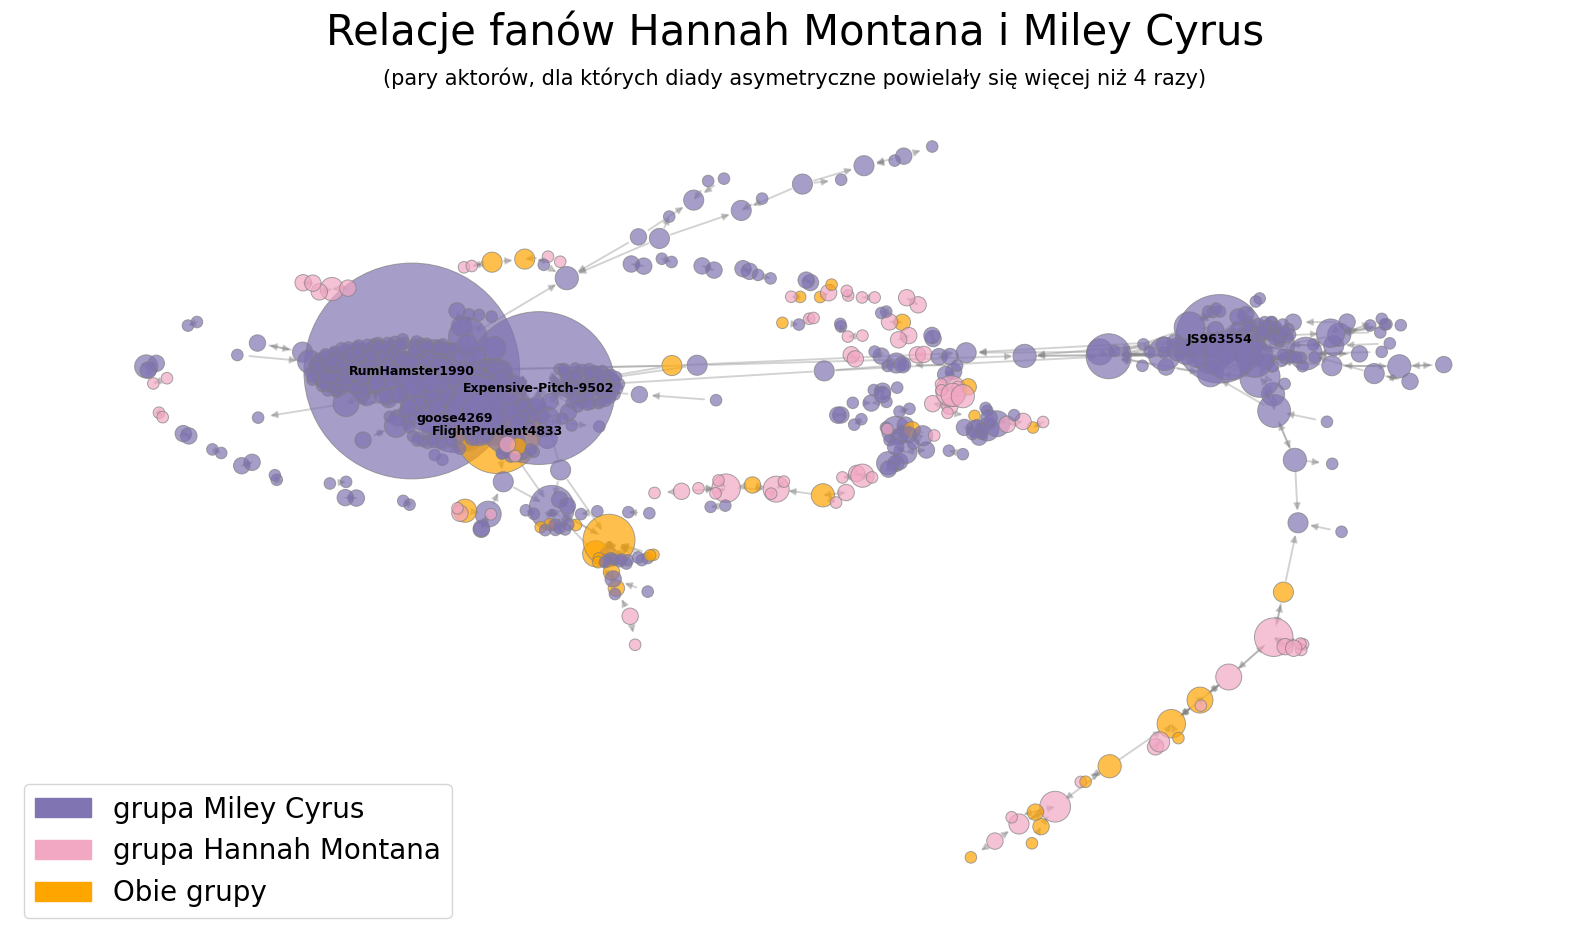

In [12]:
plt.figure(figsize=(16,16/1.618), facecolor="white")
ax = plt.gca()

pos = nx.spring_layout(
    G,
    k=1.6,              # większy rozrzut
    iterations=200,
    seed=30
)

degrees = dict(G.degree())

node_sizes = [degrees[n]*70 for n in G.nodes()]

# zwiększenie widoczności wag
edge_widths = [
    np.log1p(G[u][v].get("weight",1))*2
    for u,v in G.edges()
]

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.35,          # było 0.15
    edge_color="gray",   # zamiast white
    arrows=True
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.7,
    edgecolors="gray",
    linewidths=0.7
)

top_nodes = sorted(
    degrees,
    key=degrees.get,
    reverse=True
)[:5]

labels = {n:n for n in top_nodes}

nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=9,
    font_weight="bold",
    font_color="black"
)

plt.title(
    f"Relacje fanów Hannah Montana i Miley Cyrus",
    fontsize=30,
    pad=20
)
plt.suptitle(
    f"(pary aktorów, dla których diady asymetryczne powielały się więcej niż {n+1} razy)",
    fontsize=15,
    y=0.89
)

legend_handles = [
    mpatches.Patch(color="#8074B2", label="grupa Miley Cyrus"),
    mpatches.Patch(color="#F2A7C3", label="grupa Hannah Montana"),
    mpatches.Patch(color="orange", label="Obie grupy")
]

plt.legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=20,
    frameon=True
)

plt.axis("off")
plt.tight_layout()
plt.savefig("graf.jpeg", dpi = 600)
plt.show()

In [33]:
top_in = (
    pd.DataFrame(in_degrees.items(), columns=["author", "in_degree"])
    .sort_values("in_degree", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
 
top_in

,author,in_degree
0,RumHamster1990,871
1,Expensive-Pitch-9502,630
2,RedDalmatian885,300
3,Specific_Business_53,281
4,thecelebwanker,219
5,wordsuhh,216
6,you_sername,215
7,Material_Stomach875,213
8,FuzzyPresence8531,206
9,Yeezus023,198


In [34]:
top_out = (
    pd.DataFrame(out_degrees.items(), columns=["author", "out_degree"])
    .sort_values("out_degree", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
 
top_out

,author,out_degree
0,JS963554,265
1,RumHamster1990,250
2,goose4269,191
3,Chitchat321,162
4,Complete_Mine5530,150
5,stowRA,143
6,FlightPrudent4833,134
7,AliasDuck,117
8,SavoryWomen,113
9,fudefrak,102


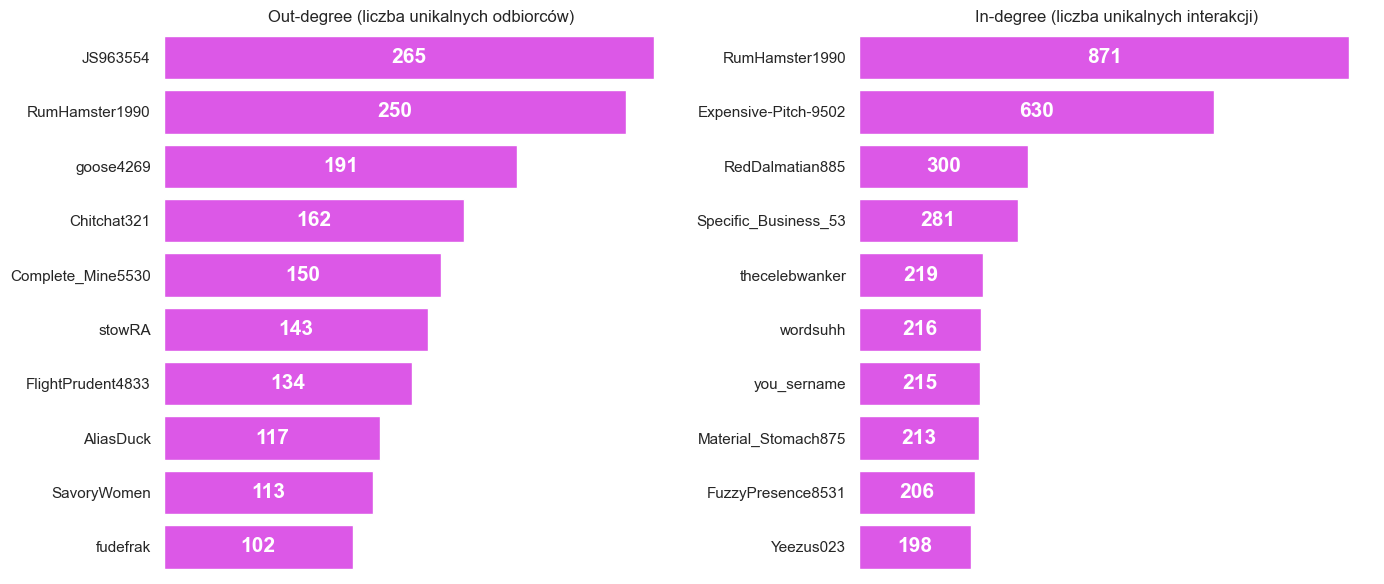

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- OUT DEGREE ---
ax0 = sns.barplot(
    data=top_out,
    x="out_degree",
    y="author",
    color="#F040FF",
    ax=axes[0]
)

axes[0].set_title("Out-degree (liczba unikalnych odbiorców)")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_xticks([])

for container in ax0.containers:
    ax0.bar_label(
        container,
        fmt="%d",
        label_type="center",
        color="white",
        fontweight="bold",
        fontsize=15
    )

# --- IN DEGREE ---
ax1 = sns.barplot(
    data=top_in,
    x="in_degree",
    y="author",
    color="#F040FF",
    ax=axes[1]
)

axes[1].set_title("In-degree (liczba unikalnych interakcji)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xticks([])

for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt="%d",
        label_type="center",
        color="white",
        fontweight="bold",
        fontsize=15
    )

axes[0].set_facecolor("none")
axes[1].set_facecolor("none")
plt.tight_layout()
plt.savefig("barplot.jpeg", dpi = 600)
plt.show()

## Graf ekskluzywności subredditów

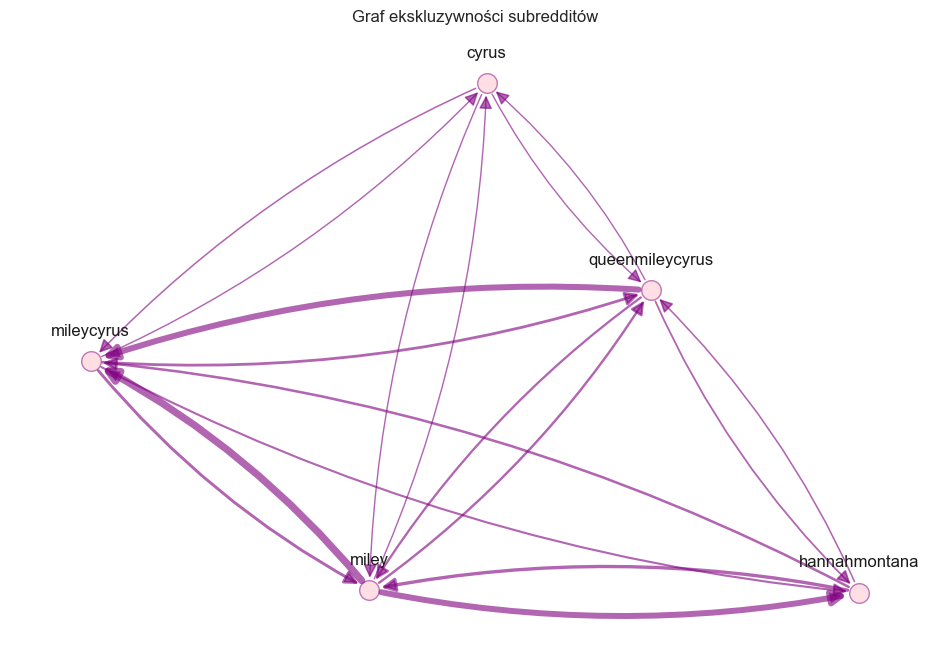

In [79]:
user_subs = data.groupby("author")["subreddit"].apply(set)
sub_users = data.groupby("subreddit")["author"].apply(set)
subreddits = list(sub_users.index)

user_degree = user_subs.apply(len)
unique_users = user_degree[user_degree == 1].index

exclusive_ratio = {}
for sub, users in sub_users.items():
    if len(users) == 0:
        exclusive_ratio[sub] = 0
    else:
        exclusive_ratio[sub] = len(users.intersection(unique_users)) / len(users)

exclusive_df = pd.DataFrame.from_dict(
    exclusive_ratio,
    orient="index",
    columns=["exclusive_ratio"]
)

edges = []

for a, b in combinations(subreddits, 2):
    users_a = sub_users[a]
    users_b = sub_users[b]

    shared = users_a & users_b
    shared_count = len(shared)

    if shared_count == 0:
        continue

    weight_ab = shared_count / len(users_a) if len(users_a) > 0 else 0
    weight_ba = shared_count / len(users_b) if len(users_b) > 0 else 0

    edges.append((a, b, weight_ab, weight_ba))

G = nx.DiGraph()

for sub in subreddits:
    G.add_node(sub, exclusive_ratio=exclusive_df.loc[sub, "exclusive_ratio"])

for a, b, wab, wba in edges:
    G.add_edge(a, b, weight=wab)
    G.add_edge(b, a, weight=wba)

out_overlap = {}
in_overlap = {}

for node in G.nodes:
    out_overlap[node] = sum(G[node][nbr]["weight"] for nbr in G.successors(node))
    in_overlap[node] = sum(G[nbr][node]["weight"] for nbr in G.predecessors(node))

centrality_df = pd.DataFrame({
    "exclusive_ratio": exclusive_df["exclusive_ratio"],
    "out_overlap": pd.Series(out_overlap),
    "in_overlap": pd.Series(in_overlap)
}).fillna(0)

pos = nx.spring_layout(G, seed=42, k = 1)

labels = {
    n: f"{n}"
    for n in G.nodes}

pos_labels = {
    n: (x, y + 0.1)
    for n, (x, y) in pos.items()}
plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=200,
    node_color="pink",
    edgecolors="purple",
    alpha = 0.5
)

edge_list = list(G.edges(data=True))
edge_widths = [d["weight"] * 25 + 1 for _, _, d in edge_list]

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[(u, v) for u, v, _ in edge_list],
    arrows=True,
    arrowstyle='-|>',
    arrowsize=20,
    width=edge_widths,
    alpha=0.6,
    connectionstyle="arc3,rad=0.1",
    edge_color="purple"
)

nx.draw_networkx_labels(
    G,
    pos_labels,
    labels=labels,
    font_size=12,
)

plt.title("Graf ekskluzywności subredditów")
plt.axis("off")
plt.savefig("Graf_ekskuzywnosci.jpeg", dpi = 600)
plt.show()

In [74]:
centrality_df

,exclusive_ratio,out_overlap,in_overlap
cyrus,0.995240,0.006058,0.002918
hannahmontana,0.920724,0.096295,0.164842
miley,0.720160,0.331494,0.128703
mileycyrus,0.905425,0.108238,0.341304
queenmileycyrus,0.853045,0.172109,0.076427
